Lima data pertama:


,X1,X2,X3,X4,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa



Jumlah seluruh data: 100

Jumlah data setiap kelas:
Species
Iris-setosa        50
Iris-versicolor    50
Name: count, dtype: int64

Data setelah label diubah:


,X1,X2,X3,X4,Species,Target
0,5.1,3.5,1.4,0.2,Iris-setosa,0
1,4.9,3.0,1.4,0.2,Iris-setosa,0
2,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5.0,3.6,1.4,0.2,Iris-setosa,0


Jumlah data training  : 80
Jumlah data validation: 20

Jumlah kelas pada data training:
Target
0    40
1    40
Name: count, dtype: int64

Jumlah kelas pada data validation:
Target
0    10
1    10
Name: count, dtype: int64

Learning rate : 0.1
Jumlah epoch  : 5
Bias awal     : 0.5
Bobot awal    : [0.5 0.5 0.5 0.5]

HASIL TRAINING


,Epoch,MSE,Accuracy (%)
0,1,0.449889,52.50
1,2,0.037452,95.00
2,3,0.024372,97.50
3,4,0.017357,97.50
4,5,0.012740,98.75



HASIL VALIDATION


,Epoch,MSE,Accuracy (%)
0,1,0.328951,50.0
1,2,0.247289,50.0
2,3,0.175892,50.0
3,4,0.119381,85.0
4,5,0.081581,100.0


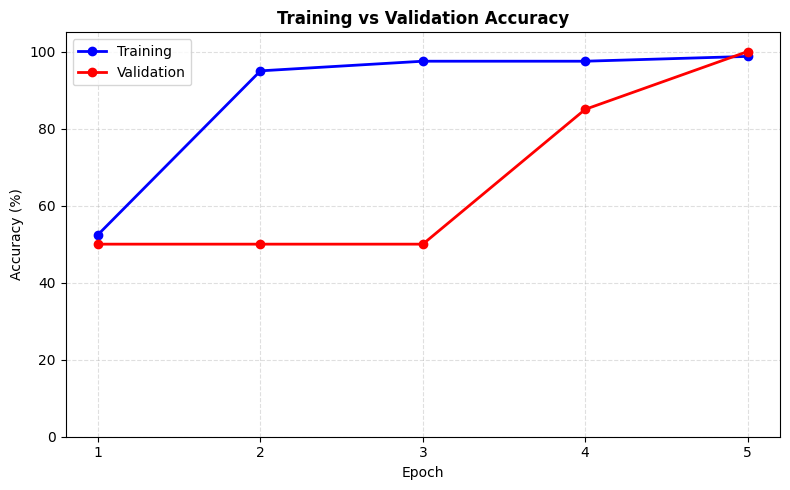

Grafik disimpan sebagai: 01_accuracy_training_validation.png


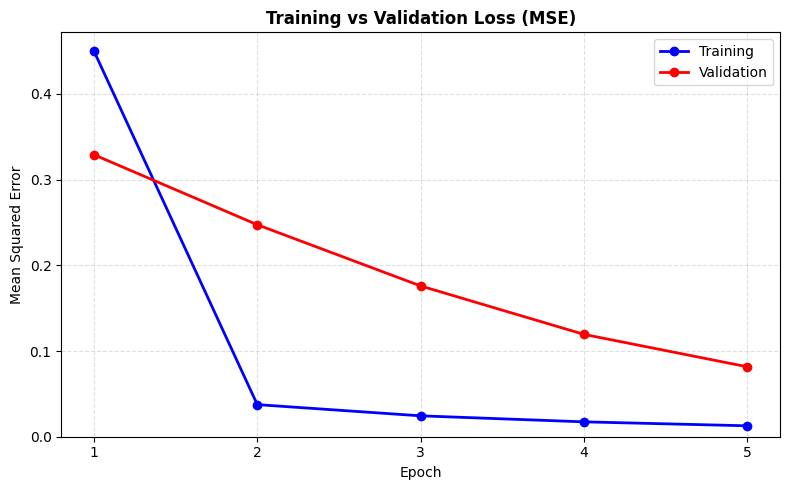

Grafik disimpan sebagai: 02_loss_training_validation.png

RINGKASAN HASIL AKHIR
Accuracy training epoch 5   : 98.75%
Accuracy validation epoch 5 : 100.00%
Loss training epoch 5       : 0.0127401582
Loss validation epoch 5     : 0.0815813694


In [ ]:
# Nama         : Aulia Fathus Tsani
# NIM          : 24/534388/PA/22661
# Mata Kuliah  : Deep Learning
# Tugas        : Assignment 1 - Single Layer Perceptron
# Data Iris dimasukkan langsung agar tidak memerlukan file CSV terpisah.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DATA_IRIS = [
    (5.1, 3.5, 1.4, 0.2, "Iris-setosa"),
    (4.9, 3.0, 1.4, 0.2, "Iris-setosa"),
    (4.7, 3.2, 1.3, 0.2, "Iris-setosa"),
    (4.6, 3.1, 1.5, 0.2, "Iris-setosa"),
    (5.0, 3.6, 1.4, 0.2, "Iris-setosa"),
    (5.4, 3.9, 1.7, 0.4, "Iris-setosa"),
    (4.6, 3.4, 1.4, 0.3, "Iris-setosa"),
    (5.0, 3.4, 1.5, 0.2, "Iris-setosa"),
    (4.4, 2.9, 1.4, 0.2, "Iris-setosa"),
    (4.9, 3.1, 1.5, 0.1, "Iris-setosa"),
    (5.4, 3.7, 1.5, 0.2, "Iris-setosa"),
    (4.8, 3.4, 1.6, 0.2, "Iris-setosa"),
    (4.8, 3.0, 1.4, 0.1, "Iris-setosa"),
    (4.3, 3.0, 1.1, 0.1, "Iris-setosa"),
    (5.8, 4.0, 1.2, 0.2, "Iris-setosa"),
    (5.7, 4.4, 1.5, 0.4, "Iris-setosa"),
    (5.4, 3.9, 1.3, 0.4, "Iris-setosa"),
    (5.1, 3.5, 1.4, 0.3, "Iris-setosa"),
    (5.7, 3.8, 1.7, 0.3, "Iris-setosa"),
    (5.1, 3.8, 1.5, 0.3, "Iris-setosa"),
    (5.4, 3.4, 1.7, 0.2, "Iris-setosa"),
    (5.1, 3.7, 1.5, 0.4, "Iris-setosa"),
    (4.6, 3.6, 1.0, 0.2, "Iris-setosa"),
    (5.1, 3.3, 1.7, 0.5, "Iris-setosa"),
    (4.8, 3.4, 1.9, 0.2, "Iris-setosa"),
    (5.0, 3.0, 1.6, 0.2, "Iris-setosa"),
    (5.0, 3.4, 1.6, 0.4, "Iris-setosa"),
    (5.2, 3.5, 1.5, 0.2, "Iris-setosa"),
    (5.2, 3.4, 1.4, 0.2, "Iris-setosa"),
    (4.7, 3.2, 1.6, 0.2, "Iris-setosa"),
    (4.8, 3.1, 1.6, 0.2, "Iris-setosa"),
    (5.4, 3.4, 1.5, 0.4, "Iris-setosa"),
    (5.2, 4.1, 1.5, 0.1, "Iris-setosa"),
    (5.5, 4.2, 1.4, 0.2, "Iris-setosa"),
    (4.9, 3.1, 1.5, 0.1, "Iris-setosa"),
    (5.0, 3.2, 1.2, 0.2, "Iris-setosa"),
    (5.5, 3.5, 1.3, 0.2, "Iris-setosa"),
    (4.9, 3.1, 1.5, 0.1, "Iris-setosa"),
    (4.4, 3.0, 1.3, 0.2, "Iris-setosa"),
    (5.1, 3.4, 1.5, 0.2, "Iris-setosa"),
    (5.0, 3.5, 1.3, 0.3, "Iris-setosa"),
    (4.5, 2.3, 1.3, 0.3, "Iris-setosa"),
    (4.4, 3.2, 1.3, 0.2, "Iris-setosa"),
    (5.0, 3.5, 1.6, 0.6, "Iris-setosa"),
    (5.1, 3.8, 1.9, 0.4, "Iris-setosa"),
    (4.8, 3.0, 1.4, 0.3, "Iris-setosa"),
    (5.1, 3.8, 1.6, 0.2, "Iris-setosa"),
    (4.6, 3.2, 1.4, 0.2, "Iris-setosa"),
    (5.3, 3.7, 1.5, 0.2, "Iris-setosa"),
    (5.0, 3.3, 1.4, 0.2, "Iris-setosa"),
    (7.0, 3.2, 4.7, 1.4, "Iris-versicolor"),
    (6.4, 3.2, 4.5, 1.5, "Iris-versicolor"),
    (6.9, 3.1, 4.9, 1.5, "Iris-versicolor"),
    (5.5, 2.3, 4.0, 1.3, "Iris-versicolor"),
    (6.5, 2.8, 4.6, 1.5, "Iris-versicolor"),
    (5.7, 2.8, 4.5, 1.3, "Iris-versicolor"),
    (6.3, 3.3, 4.7, 1.6, "Iris-versicolor"),
    (4.9, 2.4, 3.3, 1.0, "Iris-versicolor"),
    (6.6, 2.9, 4.6, 1.3, "Iris-versicolor"),
    (5.2, 2.7, 3.9, 1.4, "Iris-versicolor"),
    (5.0, 2.0, 3.5, 1.0, "Iris-versicolor"),
    (5.9, 3.0, 4.2, 1.5, "Iris-versicolor"),
    (6.0, 2.2, 4.0, 1.0, "Iris-versicolor"),
    (6.1, 2.9, 4.7, 1.4, "Iris-versicolor"),
    (5.6, 2.9, 3.6, 1.3, "Iris-versicolor"),
    (6.7, 3.1, 4.4, 1.4, "Iris-versicolor"),
    (5.6, 3.0, 4.5, 1.5, "Iris-versicolor"),
    (5.8, 2.7, 4.1, 1.0, "Iris-versicolor"),
    (6.2, 2.2, 4.5, 1.5, "Iris-versicolor"),
    (5.6, 2.5, 3.9, 1.1, "Iris-versicolor"),
    (5.9, 3.2, 4.8, 1.8, "Iris-versicolor"),
    (6.1, 2.8, 4.0, 1.3, "Iris-versicolor"),
    (6.3, 2.5, 4.9, 1.5, "Iris-versicolor"),
    (6.1, 2.8, 4.7, 1.2, "Iris-versicolor"),
    (6.4, 2.9, 4.3, 1.3, "Iris-versicolor"),
    (6.6, 3.0, 4.4, 1.4, "Iris-versicolor"),
    (6.8, 2.8, 4.8, 1.4, "Iris-versicolor"),
    (6.7, 3.0, 5.0, 1.7, "Iris-versicolor"),
    (6.0, 2.9, 4.5, 1.5, "Iris-versicolor"),
    (5.7, 2.6, 3.5, 1.0, "Iris-versicolor"),
    (5.5, 2.4, 3.8, 1.1, "Iris-versicolor"),
    (5.5, 2.4, 3.7, 1.0, "Iris-versicolor"),
    (5.8, 2.7, 3.9, 1.2, "Iris-versicolor"),
    (6.0, 2.7, 5.1, 1.6, "Iris-versicolor"),
    (5.4, 3.0, 4.5, 1.5, "Iris-versicolor"),
    (6.0, 3.4, 4.5, 1.6, "Iris-versicolor"),
    (6.7, 3.1, 4.7, 1.5, "Iris-versicolor"),
    (6.3, 2.3, 4.4, 1.3, "Iris-versicolor"),
    (5.6, 3.0, 4.1, 1.3, "Iris-versicolor"),
    (5.5, 2.5, 4.0, 1.3, "Iris-versicolor"),
    (5.5, 2.6, 4.4, 1.2, "Iris-versicolor"),
    (6.1, 3.0, 4.6, 1.4, "Iris-versicolor"),
    (5.8, 2.6, 4.0, 1.2, "Iris-versicolor"),
    (5.0, 2.3, 3.3, 1.0, "Iris-versicolor"),
    (5.6, 2.7, 4.2, 1.3, "Iris-versicolor"),
    (5.7, 3.0, 4.2, 1.2, "Iris-versicolor"),
    (5.7, 2.9, 4.2, 1.3, "Iris-versicolor"),
    (6.2, 2.9, 4.3, 1.3, "Iris-versicolor"),
    (5.1, 2.5, 3.0, 1.1, "Iris-versicolor"),
    (5.7, 2.8, 4.1, 1.3, "Iris-versicolor"),
]

data = pd.DataFrame(
    DATA_IRIS,
    columns=["X1", "X2", "X3", "X4", "Species"]
)

print("Lima data pertama:")
display(data.head())

print("\nJumlah seluruh data:", len(data))
print("\nJumlah data setiap kelas:")
print(data["Species"].value_counts())



# Mengubah label menjadi angka
data["Target"] = data["Species"].map({
    "Iris-setosa": 0,
    "Iris-versicolor": 1
})

if data["Target"].isna().any():
    label_tidak_dikenal = data.loc[
        data["Target"].isna(), "Species"
    ].unique()

    raise ValueError(
        f"Terdapat label yang tidak dikenali: {label_tidak_dikenal}"
    )

print("\nData setelah label diubah:")
display(data.head())



# Membagi data training dan validation
data_training = pd.concat(
    [
        data.iloc[0:40],
        data.iloc[50:90]
    ],
    ignore_index=True
)

data_validation = pd.concat(
    [
        data.iloc[40:50],
        data.iloc[90:100]
    ],
    ignore_index=True
)

fitur = ["X1", "X2", "X3", "X4"]

X_training = data_training[fitur].to_numpy(dtype=float)
y_training = data_training["Target"].to_numpy(dtype=int)

X_validation = data_validation[fitur].to_numpy(dtype=float)
y_validation = data_validation["Target"].to_numpy(dtype=int)

print("Jumlah data training  :", len(X_training))
print("Jumlah data validation:", len(X_validation))

print("\nJumlah kelas pada data training:")
print(data_training["Target"].value_counts().sort_index())

print("\nJumlah kelas pada data validation:")
print(data_validation["Target"].value_counts().sort_index())



learning_rate = 0.1
jumlah_epoch = 5

# Parameter awal
bias = 0.5
bobot = np.array([0.5, 0.5, 0.5, 0.5], dtype=float)

print("\nLearning rate :", learning_rate)
print("Jumlah epoch  :", jumlah_epoch)
print("Bias awal     :", bias)
print("Bobot awal    :", bobot)



def sigmoid(z):
    """
    Mengubah nilai z menjadi nilai antara 0 dan 1.
    """
    return 1 / (1 + np.exp(-z))


hasil_training = []
hasil_validation = []

# Proses training
for epoch in range(1, jumlah_epoch + 1):

    total_square_error = 0.0
    jumlah_prediksi_benar = 0

    for nomor, (x, target) in enumerate(
        zip(X_training, y_training),
        start=1
    ):

        z = np.dot(x, bobot) + bias

        output = sigmoid(z)

        if output > 0.5:
            prediksi = 1
        else:
            prediksi = 0

        error = output - target

        square_error = error ** 2

        total_square_error += square_error
        jumlah_prediksi_benar += int(prediksi == target)

        gradien = 2 * error * output * (1 - output)

        bias = bias - learning_rate * gradien
        bobot = bobot - learning_rate * gradien * x

    # Menggunakan bobot akhir training untuk validation
    bias_validation = bias
    bobot_validation = bobot.copy()

    mse_training = total_square_error / len(X_training)

    accuracy_training = (
        jumlah_prediksi_benar / len(X_training)
    )

    hasil_training.append([
        epoch,
        mse_training,
        accuracy_training
    ])

    # Proses validation
    z_validation = (
        np.dot(X_validation, bobot_validation)
        + bias_validation
    )

    output_validation = sigmoid(z_validation)

    prediksi_validation = (
        output_validation > 0.5
    ).astype(int)

    mse_validation = np.mean(
        (output_validation - y_validation) ** 2
    )

    accuracy_validation = np.mean(
        prediksi_validation == y_validation
    )

    hasil_validation.append([
        epoch,
        mse_validation,
        accuracy_validation
    ])



# Membuat tabel hasil
kolom = ["Epoch", "MSE", "Accuracy"]

tabel_training = pd.DataFrame(
    hasil_training,
    columns=kolom
)

tabel_validation = pd.DataFrame(
    hasil_validation,
    columns=kolom
)

tabel_training["Accuracy (%)"] = (
    tabel_training["Accuracy"] * 100
)

tabel_validation["Accuracy (%)"] = (
    tabel_validation["Accuracy"] * 100
)

print("\nHASIL TRAINING")
display(
    tabel_training[
        ["Epoch", "MSE", "Accuracy (%)"]
    ]
)

print("\nHASIL VALIDATION")
display(
    tabel_validation[
        ["Epoch", "MSE", "Accuracy (%)"]
    ]
)



# Grafik accuracy training dan validation
plt.figure(figsize=(8, 5))

plt.plot(
    tabel_training["Epoch"],
    tabel_training["Accuracy (%)"],
    marker="o",
    linewidth=2,
    color="blue",
    label="Training"
)

plt.plot(
    tabel_validation["Epoch"],
    tabel_validation["Accuracy (%)"],
    marker="o",
    linewidth=2,
    color="red",
    label="Validation"
)

plt.title("Training vs Validation Accuracy", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.xticks(range(1, jumlah_epoch + 1))
plt.ylim(0, 105)
plt.grid(linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig("01_accuracy_training_validation.png", dpi=300, bbox_inches="tight")
plt.show()

print("Grafik disimpan sebagai: 01_accuracy_training_validation.png")


# Grafik loss training dan validation
plt.figure(figsize=(8, 5))

plt.plot(
    tabel_training["Epoch"],
    tabel_training["MSE"],
    marker="o",
    linewidth=2,
    color="blue",
    label="Training"
)

plt.plot(
    tabel_validation["Epoch"],
    tabel_validation["MSE"],
    marker="o",
    linewidth=2,
    color="red",
    label="Validation"
)

plt.title("Training vs Validation Loss (MSE)", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.xticks(range(1, jumlah_epoch + 1))
plt.ylim(bottom=0)
plt.grid(linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig("02_loss_training_validation.png", dpi=300, bbox_inches="tight")
plt.show()

print("Grafik disimpan sebagai: 02_loss_training_validation.png")



# Menampilkan hasil akhir
print("\nRINGKASAN HASIL AKHIR")

print(
    f"Accuracy training epoch 5   : "
    f"{tabel_training['Accuracy (%)'].iloc[-1]:.2f}%"
)

print(
    f"Accuracy validation epoch 5 : "
    f"{tabel_validation['Accuracy (%)'].iloc[-1]:.2f}%"
)

print(
    f"Loss training epoch 5       : "
    f"{tabel_training['MSE'].iloc[-1]:.10f}"
)

print(
    f"Loss validation epoch 5     : "
    f"{tabel_validation['MSE'].iloc[-1]:.10f}"
)
